**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: MLOPS**

Tecnológico de Monterrey


**Proyecto Entrega 1**


---

# Instalación de Librerias e imports

In [271]:
!python3 --version
!git --version
!pip show dvc || pip install -q dvc
!pip show pandas || pip install -q pandas
!pip show scikit-learn || pip install -q scikit-learn
!pip show "dvc[gdrive]" || pip install "dvc[gdrive]" -q
!pip show cryptography || !pip install cryptography -q
!pip install category_encoders

Python was not found; run without arguments to install from the Microsoft Store, or disable this shortcut from Settings > Apps > Advanced app settings > App execution aliases.


git version 2.43.0.windows.1
Name: dvc
Version: 3.63.0
Summary: Git for data scientists - manage your code and data together
Home-page: 
Author: 
Author-email: Dmitry Petrov <dmitry@dvc.org>
License: 
Location: c:\users\cdls1\onedrive\documentos\chatbot\practicas\.conda\lib\site-packages
Requires: attrs, celery, colorama, configobj, distro, dpath, dulwich, dvc-data, dvc-http, dvc-objects, dvc-render, dvc-studio-client, dvc-task, flatten_dict, flufl.lock, fsspec, funcy, grandalf, gto, hydra-core, iterative-telemetry, kombu, networkx, omegaconf, packaging, pathspec, platformdirs, psutil, pydot, pygtrie, pyparsing, requests, rich, ruamel.yaml, scmrepo, shortuuid, shtab, tabulate, tomlkit, tqdm, voluptuous, zc.lockfile
Required-by: dvc-gdrive
Name: pandas
Version: 2.1.1
Summary: Powerful data structures for data analysis, time series, and statistics
Home-page: https://pandas.pydata.org
Author: 
Author-email: The Pandas Development Team <pandas-dev@python.org>
License: BSD 3-Clause License


Name: cryptography
Version: 41.0.3
Summary: cryptography is a package which provides cryptographic recipes and primitives to Python developers.
Home-page: 
Author: 
Author-email: The Python Cryptographic Authority and individual contributors <cryptography-dev@python.org>
License: Apache-2.0 OR BSD-3-Clause
Location: c:\users\cdls1\onedrive\documentos\chatbot\practicas\.conda\lib\site-packages
Requires: cffi
Required-by: asyncssh, PyDrive2, pyOpenSSL

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import dvc.api
import json
from cryptography.fernet import Fernet
import os
import subprocess
from pathlib import Path
import ruamel.yaml
import scipy.stats as stats
from scipy.stats.distributions import norm
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from category_encoders.binary import BinaryEncoder
import os,  warnings, joblib
from scipy.stats import loguniform, randint, uniform

from sklearn.preprocessing import OneHotEncoder, PowerTransformer, MinMaxScaler, StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor

warnings.filterwarnings("ignore")

Path("models").mkdir(exist_ok=True)
Path("predictions").mkdir(exist_ok=True)


# ***Setup del versionado de datos para el proyecto***

### Constantes del repositorio

In [273]:
REPO_URL = "."
REVISION = "Development"
CLEAN_CSV_PATH = "online_news_clean.csv"

# Nota: Este proyecto se encuentra trabajando localmente en una carpeta en la que previamente ya se hizo el checkout a la rama de Development.

### Metodos de dvc

In [274]:
# Las variables para autenticarse en google fueron almacenadas en un secrets_encrypted.json file. 
# Preguntar a Andre los pasos para obtener un authKey de google cloud de ser necesario, si no tambien se puede hacer localmente
def getSecret(token:str):
    with open("key.key", "rb") as key_file:
        key = key_file.read()
    with open("secrets_encrypted.json", "rb") as f:
        encrypted_data = f.read()
    fernet = Fernet(key)
    decrypted = fernet.decrypt(encrypted_data)
    secrets = json.loads(decrypted.decode())
    return secrets[token]

In [275]:
# Metodo para obtener metricas
def save_metrics(df:pd.DataFrame, path:str):
    metrics = {
        "rows": int(df.shape[0]),
        "columns": int(df.shape[1]),
        "null_values_total": int(df.isna().sum().sum())
    }
    os.makedirs(Path(path).parent, exist_ok=True)
    with open(path, "w") as f:
        json.dump(metrics, f, indent=2)

In [276]:
def dvc_add_or_commit(path: Path):
    dvc_file = path.with_suffix(path.suffix + ".dvc")
    if dvc_file.exists():
        subprocess.run(["dvc", "commit", "-f", str(dvc_file)], check=False)
    else:
        subprocess.run(["dvc", "add", str(path)], check=True)
    return dvc_file

In [277]:
# Metodo para hacer commit de los cambios hechos
def commit_df_change(dataframe: pd.DataFrame, commit_title: str, path=CLEAN_CSV_PATH):
    csv_path = Path(path)
    metrics_path = Path("metrics") / f"{csv_path.stem}.json"

    csv_path.parent.mkdir(parents=True, exist_ok=True)
    dataframe.to_csv(csv_path, index=False)
    save_metrics(dataframe, metrics_path)

    csv_dvc     = dvc_add_or_commit(csv_path)
    metrics_dvc = dvc_add_or_commit(metrics_path)

    subprocess.run(["git", "add", str(csv_dvc), str(metrics_dvc)], check=True)
    subprocess.run(["git", "commit", "-m", commit_title], check=False)
    subprocess.run(["dvc", "push"], check=False)

    print(f"Commit DVC creado: {commit_title}")

In [278]:
# Metodo para obtener un dataframe a partir de un commit
def get_df_from_commit(path:str, rev:str, repo=REPO_URL, delimiter=','):
    with dvc.api.open(
        path=path,
        repo=repo,
        rev=rev,
        mode="r"
    ) as fd:
        return pd.read_csv(fd, delimiter=delimiter)

In [279]:
# Metodo para obtener las diferencias entre dos commits:
def get_commit_metrics(old_rev:str, new_rev:str, byCommitTitle=True, metrics_path="metrics/online_news_clean.json", repo=REPO_URL):
    if byCommitTitle:
        result1 = subprocess.run(
            ["git", "log", "--oneline", "--grep", old_rev],
            check=False,
            capture_output=True,
            text=True
        )
        result2 = subprocess.run(
            ["git", "log", "--oneline", "--grep", new_rev],
            check=False,
            capture_output=True,
            text=True
        )
        if not (result1):
            print (f"No hay un commit con el nombre {old_rev}")
        if not (result2):
            print (f"No hay un commit con el nombre {new_rev}")
        old_rev = result1.stdout.split(" ")[0]
        new_rev = result2.stdout.split(" ")[0]

    def _read_metrics(rev):
        try:
            with dvc.api.open(metrics_path, repo=repo, rev=rev, mode="r") as f:
                return json.load(f)
        except Exception as e:
            print(f"No se pudo leer métricas en {rev}: {e}")
            return None
    metrics_old = _read_metrics(old_rev)
    metrics_new = _read_metrics(new_rev)
    
    if not metrics_old or not metrics_new:
        print("No se pudieron leer ambas versiones de métricas.")
        return None

    # Calcular diferencia
    diff = {}
    for key in metrics_new.keys():
        old_val = metrics_old.get(key, None)
        new_val = metrics_new[key]
        if isinstance(new_val, (int, float)) and old_val is not None:
            diff[key] = new_val - old_val
        else:
            diff[key] = None

    return {
        "old_rev": old_rev,
        "new_rev": new_rev,
        "metrics_old": metrics_old,
        "metrics_new": metrics_new,
        "diff": diff
    }

In [280]:
# Metodo para obtener ultimos 10 commits:
def get_last_commits(limit:int):
    return subprocess.run(
            ["git", "log", "--oneline", "-n", str(limit)],
            check=True,
        )

### Inicializar dvc en local

In [281]:
![ -d .dvc ] || dvc init -q

'[' is not recognized as an internal or external command,
operable program or batch file.


### Configuracion dvc remoto (en caso de haber configurado google cloud api)

***Necesitas una api de servicios. Si ya le preguntaste a Andre y tienes el archivo key.key, descomenta este codigo. De lo contrario, si deseas correrlo localmnete, puedes hacerlo sin descomentar el codigo***

In [282]:
#drive_folder = getSecret("drive_folder")
#client_secret = getSecret("client_secret")
#client_id = getSecret("client_id")

In [283]:
#!dvc remote add -d myremote gdrive://$drive_folder -f
#!dvc remote modify --local myremote gdrive_client_id $client_id
#!dvc remote modify --local myremote gdrive_client_secret $client_secret
#!git add .dvc/config
#!git commit -m "Configure remote DVC in Google Drive"

In [284]:
!dvc remote add -d myremote ../dvc_remote -f


Setting 'myremote' as a default remote.


### Verificación de los archivos y dvc

In [285]:
!dvc list .
!dvc status

.dvcignore
.gitignore
Entrega1_Equipo45.ipynb
Readme.md
metrics
models
online_news_clean.csv
online_news_clean.csv.dvc
online_news_modified.csv
predictions
secrets_encrypted.json
Data and pipelines are up to date.


# ***EDA***

Estadísticas descriptivas para todas las variables del dataframe original

In [286]:
# Dataframe a partir de dvc
df = get_df_from_commit("online_news_modified.csv", REVISION)

In [287]:
#PRIMERAS FILAS
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares,mixed_type_col
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594466988,0.999999992308,0.815384609112,4.0,2.0,1.0,...,0.7,-0.35,-0.6,-3.4000000000000004,0.5,-0.1875,0.0,0.1875,593.0,bad
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743080614,0.999999993289,0.79194630341,3.0,1.0,1.0,...,0.7,-0.11875,-0.125,-0.1,0.0,0.0,0.5,0.0,711.0,639
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575129530699,0.999999991597,0.66386554064,3.0,1.0,1.0,...,1.0,-0.466666666667,-0.8,-0.133333333333,0.0,0.0,0.5,0.0,1500.0,unknown
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503787877834,0.999999996904,0.665634672862,9.0,0.0,1.0,...,0.8,-0.369696969697,-0.6,-0.166666666667,0.0,0.0,0.5,NaN,1200.0,688
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.41564561695,0.999999998565,0.540889525766,19.0,19.0,20.0,...,1.0,-0.220192307692,error,-0.05,0.454545454545,0.136363636364,0.0454545454545,0.136363636364,505.0,579


In [288]:
#INFORMACIÓN DE TIPOS DE DATOS
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40436 entries, 0 to 40435
Data columns (total 62 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   url                            40027 non-null  object
 1   timedelta                      39994 non-null  object
 2   n_tokens_title                 39976 non-null  object
 3   n_tokens_content               39963 non-null  object
 4   n_unique_tokens                39985 non-null  object
 5   n_non_stop_words               39977 non-null  object
 6   n_non_stop_unique_tokens       39956 non-null  object
 7   num_hrefs                      39986 non-null  object
 8   num_self_hrefs                 39988 non-null  object
 9   num_imgs                       39980 non-null  object
 10  num_videos                     39987 non-null  object
 11  average_token_length           40031 non-null  object
 12  num_keywords                   39981 non-null  object
 13  d

In [289]:
#ESTADÍSTICAS DESCRIPTIVAS
df.describe()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares,mixed_type_col
count,40027,39994,39976,39963,39985,39977,39956,39986,39988,39980,...,39979,39975,39976,39996,39983,39950,39961,39981,39949,36362
unique,39313,1677,363,3509,28030,2542,24007,526,379,390,...,402,14718,466,428,1120,1228,989,1062,2311,1002
top,NAN,84.0,10.0,0.0,0.0,0.0,0.0,5.0,2.0,1.0,...,1.0,0.0,-0.5,-0.05,0.0,0.0,0.5,0.0,1100.0,unknown
freq,17,100,6984,1131,1131,1116,1112,3282,7210,17112,...,14009,2420,6472,9393,17096,18940,19379,18937,2184,4034


In [290]:
#ANÁLISIS DE VALORES NULOS
null_counts = df.isnull().sum()
null_percentages = (df.isnull().sum() / len(df)) * 100
null_info = pd.DataFrame({
    'Nulos': null_counts,
    'Porcentaje': null_percentages
})
null_info = null_info[null_info['Nulos'] > 0].sort_values('Nulos', ascending=False)
print(null_info)

                            Nulos  Porcentaje
mixed_type_col               4074   10.075181
data_channel_is_socmed        492    1.216738
LDA_00                        491    1.214265
global_rate_negative_words    488    1.206845
shares                        487    1.204372
...                           ...         ...
url                           409    1.011475
data_channel_is_bus           407    1.006529
average_token_length          405    1.001583
kw_max_max                    405    1.001583
kw_avg_avg                    401    0.991691

[62 rows x 2 columns]


In [291]:
#ANÁLISIS DE VALORES VACÍOS (strings vacíos)
empty_counts = {}
for col in df.columns:
    if df[col].dtype == 'object':
        empty_count = (df[col] == '').sum()
        if empty_count > 0:
            empty_counts[col] = empty_count

if empty_counts:
    print("\nValores vacíos encontrados:")
    for col, count in empty_counts.items():
        print(f"   {col}: {count} ({count/len(df)*100:.2f}%)")
else:
    print("\nNo se encontraron valores vacíos (strings vacíos)")


No se encontraron valores vacíos (strings vacíos)


In [292]:
#ANÁLISIS DE DUPLICADOS
duplicates = df.duplicated().sum()
print(f"\nFilas duplicadas: {duplicates}")


Filas duplicadas: 0


In [293]:
#ANÁLISIS DE COLUMNAS
print("\nColumnas numéricas vs categóricas:")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"   Numéricas: {len(numeric_cols)}")
print(f"   Categóricas/Object: {len(categorical_cols)}")

if categorical_cols:
    print("\nColumnas categóricas:")
    for col in categorical_cols:
        print(f"   - {col}")


Columnas numéricas vs categóricas:
   Numéricas: 0
   Categóricas/Object: 62

Columnas categóricas:
   - url
   - timedelta
   - n_tokens_title
   - n_tokens_content
   - n_unique_tokens
   - n_non_stop_words
   - n_non_stop_unique_tokens
   - num_hrefs
   - num_self_hrefs
   - num_imgs
   - num_videos
   - average_token_length
   - num_keywords
   - data_channel_is_lifestyle
   - data_channel_is_entertainment
   - data_channel_is_bus
   - data_channel_is_socmed
   - data_channel_is_tech
   - data_channel_is_world
   - kw_min_min
   - kw_max_min
   - kw_avg_min
   - kw_min_max
   - kw_max_max
   - kw_avg_max
   - kw_min_avg
   - kw_max_avg
   - kw_avg_avg
   - self_reference_min_shares
   - self_reference_max_shares
   - self_reference_avg_sharess
   - weekday_is_monday
   - weekday_is_tuesday
   - weekday_is_wednesday
   - weekday_is_thursday
   - weekday_is_friday
   - weekday_is_saturday
   - weekday_is_sunday
   - is_weekend
   - LDA_00
   - LDA_01
   - LDA_02
   - LDA_03
   - LDA

In [294]:
#ANÁLISIS DE VALORES ÚNICOS
if categorical_cols:
    for col in categorical_cols[:10]:  # Primeras 10 para no saturar
        unique_count = df[col].nunique()
        print(f"\n{col}:")
        print(f"   Valores únicos: {unique_count}")
        if unique_count < 20:
            print(f"   Valores: {df[col].unique()[:10]}")
else:
    print("\n   ✓ No hay columnas categóricas para analizar")


url:
   Valores únicos: 39313

timedelta:
   Valores únicos: 1677

n_tokens_title:
   Valores únicos: 363

n_tokens_content:
   Valores únicos: 3509

n_unique_tokens:
   Valores únicos: 28030

n_non_stop_words:
   Valores únicos: 2542

n_non_stop_unique_tokens:
   Valores únicos: 24007

num_hrefs:
   Valores únicos: 526

num_self_hrefs:
   Valores únicos: 379

num_imgs:
   Valores únicos: 390


# ***LIMPIEZA DE DATOS***

In [295]:
#PROCESO DE LIMPIEZA
df_clean = df.copy()
commit_df_change(df_clean, "Copy of original dataframe")

Commit DVC creado: Copy of original dataframe


In [296]:
#CONVERSIÓN DE TIPOS DE DATOS
# Intentar convertir columnas que deberían ser numéricas
print("\nConvirtiendo columnas a tipos numéricos...")
conversion_count = 0

for col in df_clean.columns:
    if col != 'url':  # Excluir URL
        try:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
            print(f"   ✓ {col} convertida a numérico")
            conversion_count += 1
        except:
            pass

print(f"\nTotal de columnas convertidas: {conversion_count}")
print("\nTipos de datos después de conversión:")
print(df_clean.dtypes)
commit_df_change(df_clean, "Converted columns into numeric types")


Convirtiendo columnas a tipos numéricos...
   ✓ timedelta convertida a numérico
   ✓ n_tokens_title convertida a numérico
   ✓ n_tokens_content convertida a numérico
   ✓ n_unique_tokens convertida a numérico
   ✓ n_non_stop_words convertida a numérico
   ✓ n_non_stop_unique_tokens convertida a numérico
   ✓ num_hrefs convertida a numérico
   ✓ num_self_hrefs convertida a numérico
   ✓ num_imgs convertida a numérico
   ✓ num_videos convertida a numérico
   ✓ average_token_length convertida a numérico
   ✓ num_keywords convertida a numérico
   ✓ data_channel_is_lifestyle convertida a numérico
   ✓ data_channel_is_entertainment convertida a numérico
   ✓ data_channel_is_bus convertida a numérico
   ✓ data_channel_is_socmed convertida a numérico
   ✓ data_channel_is_tech convertida a numérico
   ✓ data_channel_is_world convertida a numérico
   ✓ kw_min_min convertida a numérico
   ✓ kw_max_min convertida a numérico
   ✓ kw_avg_min convertida a numérico
   ✓ kw_min_max convertida a numéri

In [297]:
#NORMALIZACIÓN DE COLUMNAS BOOLEANAS
# Definir columnas que deben ser booleanas (0 o 1)
boolean_cols = [
    'data_channel_is_lifestyle',
    'data_channel_is_entertainment',
    'data_channel_is_bus',
    'data_channel_is_socmed',
    'data_channel_is_tech',
    'data_channel_is_world',
    'weekday_is_monday',
    'weekday_is_tuesday',
    'weekday_is_wednesday',
    'weekday_is_thursday',
    'weekday_is_friday',
    'weekday_is_saturday',
    'weekday_is_sunday',
    'is_weekend'
]

print("\nNormalizando columnas booleanas (0 si es 0, 1 si es cualquier otro valor):")
for col in boolean_cols:
    if col in df_clean.columns:
        # Mostrar valores únicos antes de la normalización
        unique_before = df_clean[col].unique()
        print(f"\n   {col}:")
        print(f"      Valores únicos antes: {sorted(unique_before[~pd.isna(unique_before)])}")

        # Normalizar: 0 se queda como 0, cualquier otro valor se convierte en 1
        df_clean.loc[:, col] = df_clean[col].apply(lambda x: 0 if x == 0 else (1 if pd.notna(x) else np.nan))

        # Mostrar valores únicos después de la normalización
        unique_after = df_clean[col].unique()
        print(f"      Valores únicos después: {sorted(unique_after[~pd.isna(unique_after)])}")

        # Contar valores
        value_counts = df_clean[col].value_counts()
        print(f"      Distribución: 0={value_counts.get(0, 0)}, 1={value_counts.get(1, 0)}")

print(f"\n✓ {len([col for col in boolean_cols if col in df_clean.columns])} columnas booleanas normalizadas")

commit_df_change(df_clean, "Normalized boolean columns")


Normalizando columnas booleanas (0 si es 0, 1 si es cualquier otro valor):

   data_channel_is_lifestyle:
      Valores únicos antes: [0.0, 1.0, 14.0, 15.0, 45.0, 46.0, 58.0, 63.0, 91.0, 97.0, 101.0, 106.0, 107.0, 117.0, 118.0, 125.0, 126.0, 137.0, 141.0, 144.0, 147.0, 150.0, 154.0, 161.0, 165.0, 169.0, 172.0, 174.0, 181.0, 190.0, 192.0, 193.0, 197.0, 206.0, 207.0, 211.0, 234.0, 246.0, 249.0, 259.0, 268.0, 272.0, 279.0, 282.0, 284.0, 286.0, 296.0, 298.0, 299.0, 300.0, 304.0, 309.0, 310.0, 311.0, 314.0, 323.0, 325.0, 328.0, 336.0, 338.0, 349.0, 353.0, 357.0, 359.0, 380.0, 381.0, 383.0, 385.0, 388.0, 390.0, 393.0, 394.0, 395.0, 396.0, 399.0, 411.0, 417.0, 422.0, 426.0, 437.0, 445.0, 449.0, 451.0, 453.0, 457.0, 464.0, 465.0, 472.0, 475.0, 479.0, 484.0, 485.0, 488.0, 494.0, 502.0, 504.0, 513.0, 517.0, 519.0, 525.0, 529.0, 538.0, 539.0, 541.0, 550.0, 552.0, 557.0, 559.0, 561.0, 565.0, 570.0, 577.0, 578.0, 580.0, 581.0, 585.0, 587.0, 588.0, 591.0, 599.0, 606.0, 610.0, 614.0, 620.0, 630.0, 6

In [298]:
#ANÁLISIS DE OUTLIERS
# Seleccionar columnas numéricas importantes (excluyendo las booleanas)
important_numeric_cols = ['n_tokens_title', 'n_tokens_content', 'num_hrefs',
                          'num_imgs', 'num_videos', 'shares']

for col in important_numeric_cols:
    if col in df_clean.columns and df_clean[col].dtype in ['int64', 'float64']:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
        print(f"\n{col}:")
        print(f"   Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
        print(f"   Límites: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"   Outliers: {outliers} ({outliers/len(df_clean)*100:.2f}%)")


n_tokens_title:
   Q1: 9.00, Q3: 12.00, IQR: 3.00
   Límites: [4.50, 16.50]
   Outliers: 562 (1.39%)

n_tokens_content:
   Q1: 247.00, Q3: 725.00, IQR: 478.00
   Límites: [-470.00, 1442.00]
   Outliers: 2042 (5.05%)

num_hrefs:
   Q1: 4.00, Q3: 14.00, IQR: 10.00
   Límites: [-11.00, 29.00]
   Outliers: 2561 (6.33%)

num_imgs:
   Q1: 1.00, Q3: 5.00, IQR: 4.00
   Límites: [-5.00, 11.00]
   Outliers: 5501 (13.60%)

num_videos:
   Q1: 0.00, Q3: 1.00, IQR: 1.00
   Límites: [-1.50, 2.50]
   Outliers: 3181 (7.87%)

shares:
   Q1: 950.00, Q3: 2800.00, IQR: 1850.00
   Límites: [-1825.00, 5575.00]
   Outliers: 4728 (11.69%)


In [299]:
# Eliminar duplicados
rows_before = len(df_clean)
duplicates_removed = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()
print(f"\n1. Duplicados eliminados: {duplicates_removed}")
commit_df_change(df_clean, "Drop duplicates")

# Eliminar filas con demasiados valores nulos (más del 50%)
threshold = len(df_clean.columns) * 0.5
rows_with_many_nulls = df_clean.isnull().sum(axis=1) > threshold
df_clean = df_clean[~rows_with_many_nulls]
print(f"2. Filas con >50% nulos eliminadas: {rows_with_many_nulls.sum()}")
commit_df_change(df_clean, "Drop rows with more than 50 percent of null values")


# Eliminar columnas con demasiados valores nulos (más del 50%)
null_percentages = (df_clean.isnull().sum() / len(df_clean)) * 100
cols_to_drop = null_percentages[null_percentages > 50].index.tolist()
if cols_to_drop:
    df_clean = df_clean.drop(columns=cols_to_drop)
    print(f"3. Columnas con >50% nulos eliminadas: {cols_to_drop}")
else:
    print(f"3. No hay columnas con >50% nulos")
commit_df_change(df_clean, "Drop columns with more than 50 percent of null values")


# Imputar valores nulos en columnas numéricas NO booleanas con la mediana
numeric_cols_with_nulls = df_clean.select_dtypes(include=[np.number]).columns[
    df_clean.select_dtypes(include=[np.number]).isnull().any()
].tolist()


# Excluir columnas booleanas de la imputación con mediana
numeric_cols_for_imputation = [col for col in numeric_cols_with_nulls if col not in boolean_cols]

if numeric_cols_for_imputation:
    print(f"\n4. Imputando valores nulos en columnas numéricas (NO booleanas) con la mediana:")
    for col in numeric_cols_for_imputation:
        median_val = df_clean[col].median()
        nulls_count = df_clean[col].isnull().sum()
        df_clean.loc[:, col] = df_clean[col].fillna(median_val)
        print(f"   - {col}: {nulls_count} valores imputados con {median_val:.2f}")
else:
    print(f"\n4. ✓ No hay valores nulos en columnas numéricas (NO booleanas) para imputar")
commit_df_change(df_clean, "Impute missing values in non-boolean numeric columns using the median")


# Imputar valores nulos en columnas booleanas con 0 (valor más conservador)
boolean_cols_with_nulls = [col for col in boolean_cols if col in df_clean.columns and df_clean[col].isnull().any()]
if boolean_cols_with_nulls:
    print(f"\n5. Imputando valores nulos en columnas booleanas con 0:")
    for col in boolean_cols_with_nulls:
        nulls_count = df_clean[col].isnull().sum()
        df_clean.loc[:, col] = df_clean[col].fillna(0)
        print(f"   - {col}: {nulls_count} valores imputados con 0")
else:
    print(f"\n5. ✓ No hay valores nulos en columnas booleanas")
commit_df_change(df_clean, "Impute missing values in boolean columns with 0")

# Eliminar outliers extremos en shares (variable objetivo común)
if 'shares' in df_clean.columns:
    Q1 = df_clean['shares'].quantile(0.25)
    Q3 = df_clean['shares'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR  # Usar 3*IQR para outliers extremos
    upper_bound = Q3 + 3 * IQR

    outliers_mask = (df_clean['shares'] < lower_bound) | (df_clean['shares'] > upper_bound)
    outliers_count = outliers_mask.sum()
    df_clean = df_clean[~outliers_mask]
    print(f"\n6. Outliers extremos en 'shares' eliminados: {outliers_count}")
    commit_df_change(df_clean, "Deleted extreme outliers in deleted shares")

# Eliminar valores negativos en columnas que no deberían tenerlos (excluyendo booleanas)
print("\n7. Verificando valores negativos en columnas que deberían ser positivas:")
positive_cols = ['n_tokens_title', 'n_tokens_content', 'num_hrefs', 'num_imgs',
                 'num_videos', 'shares']

negative_found = False
for col in positive_cols:
    if col in df_clean.columns and df_clean[col].dtype in ['int64', 'float64']:
        negative_mask = df_clean[col] < 0
        negative_count = negative_mask.sum()
        if negative_count > 0:
            df_clean = df_clean[~negative_mask]
            print(f"   - {col}: {negative_count} valores negativos eliminados")
            negative_found = True

if not negative_found:
    print("   ✓ No se encontraron valores negativos en las columnas verificadas")
commit_df_change(df_clean, "Deleting negative values in columns that must be positives")


rows_after = len(df_clean)


1. Duplicados eliminados: 1
Commit DVC creado: Drop duplicates
2. Filas con >50% nulos eliminadas: 0
Commit DVC creado: Drop rows with more than 50 percent of null values
3. No hay columnas con >50% nulos
Commit DVC creado: Drop columns with more than 50 percent of null values

4. Imputando valores nulos en columnas numéricas (NO booleanas) con la mediana:
   - timedelta: 597 valores imputados con 342.00
   - n_tokens_title: 614 valores imputados con 10.00
   - n_tokens_content: 631 valores imputados con 413.00
   - n_unique_tokens: 602 valores imputados con 0.54
   - n_non_stop_words: 581 valores imputados con 1.00
   - n_non_stop_unique_tokens: 637 valores imputados con 0.69
   - num_hrefs: 597 valores imputados con 8.00
   - num_self_hrefs: 608 valores imputados con 3.00
   - num_imgs: 596 valores imputados con 1.00
   - num_videos: 587 valores imputados con 0.00
   - average_token_length: 534 valores imputados con 4.67
   - num_keywords: 605 valores imputados con 7.00
   - kw_min_

In [300]:
get_last_commits(8)

CompletedProcess(args=['git', 'log', '--oneline', '-n', '8'], returncode=0)

In [301]:
result = get_commit_metrics("Normalized boolean columns", "Deleted extreme outliers in deleted shares")

print("Métricas actuales:", result["metrics_new"])
print("Métricas anteriores:", result["metrics_old"])
print("Diferencias:", result["diff"])

Métricas actuales: {'rows': 37471, 'columns': 62, 'null_values_total': 373}
Métricas anteriores: {'rows': 40436, 'columns': 62, 'null_values_total': 48597}
Diferencias: {'rows': -2965, 'columns': 0, 'null_values_total': -48224}


In [302]:
#RESUMEN FINAL
print("\n" + "="*80)
print("RESUMEN FINAL DE LIMPIEZA")
print("="*80)
print(f"\nFilas originales: {rows_before:,}")
print(f"Filas después de limpieza: {rows_after:,}")
print(f"Filas eliminadas: {rows_before - rows_after:,} ({(rows_before - rows_after)/rows_before*100:.2f}%)")
print(f"Columnas finales: {df_clean.shape[1]}")

print("\nValores nulos restantes:")
remaining_nulls = df_clean.isnull().sum().sum()
print(f"   Total: {remaining_nulls}")

# Guardar el dataset limpio
#df_clean.to_csv('online_news_clean.csv', index=False)
#print("\n✓ Dataset limpio guardado como 'online_news_clean.csv'")

print("\nPrimeras filas del dataset limpio:")
print(df_clean.head())

print("\nInformación del dataset limpio:")
print(df_clean.info())



RESUMEN FINAL DE LIMPIEZA

Filas originales: 40,436
Filas después de limpieza: 37,471
Filas eliminadas: 2,965 (7.33%)
Columnas finales: 62

Valores nulos restantes:
   Total: 373

Primeras filas del dataset limpio:
                                                 url  timedelta  \
0  http://mashable.com/2013/01/07/amazon-instant-...      731.0   
1  http://mashable.com/2013/01/07/ap-samsung-spon...      731.0   
2  http://mashable.com/2013/01/07/apple-40-billio...      731.0   
3  http://mashable.com/2013/01/07/astronaut-notre...      731.0   
4   http://mashable.com/2013/01/07/att-u-verse-apps/      731.0   

   n_tokens_title  n_tokens_content  n_unique_tokens  n_non_stop_words  \
0            12.0             219.0         0.663594               1.0   
1             9.0             255.0         0.604743               1.0   
2             9.0             211.0         0.575130               1.0   
3             9.0             531.0         0.503788               1.0   
4          

# **Parte 2**. Análisis Exploratorio

In [303]:
# Importamos librerías para esta etapa
import matplotlib.pyplot as plt

In [304]:
#Primeras 5 columnas del df limpio
df_clean.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares,mixed_type_col
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.7,-0.350000,-0.600,-3.400000,0.500000,-0.187500,0.000000,0.187500,593.0,494.0
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711.0,639.0
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500.0,494.0
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200.0,688.0
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505.0,579.0


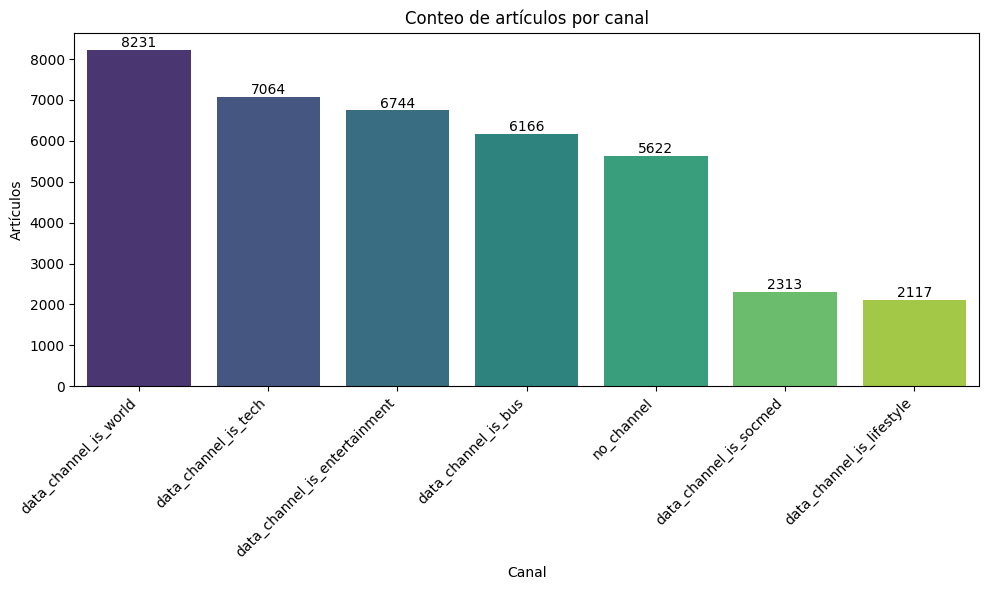

In [305]:
channel_cols = ['data_channel_is_lifestyle', 'data_channel_is_entertainment', 'data_channel_is_bus',
                'data_channel_is_socmed', 'data_channel_is_tech', 'data_channel_is_world']

# Calcula los artículos por canal
channel_counts = df_clean[channel_cols].sum()

# Calcula los artículos que no tienen chanel
df_clean['no_channel'] = (df_clean[channel_cols].sum(axis=1) == 0).astype(int)
no_channel_count = df_clean['no_channel'].sum()

# Agrega el conteo de no_channel
channel_counts['no_channel'] = no_channel_count

# Convierte el conteo a df para graficar
channel_counts_df = channel_counts.reset_index()
channel_counts_df.columns = ['Channel', 'Count']
channel_counts_df = channel_counts_df.sort_values(by='Count', ascending=False)

# Grafica el conteo de artículos por canal
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Channel', y='Count', data=channel_counts_df, palette='viridis', hue='Channel', legend=False) # Assign x to hue and set legend=False
plt.title('Conteo de artículos por canal')
plt.xlabel('Canal')
plt.ylabel('Artículos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Agrega etiquetas de datos
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')


plt.show()

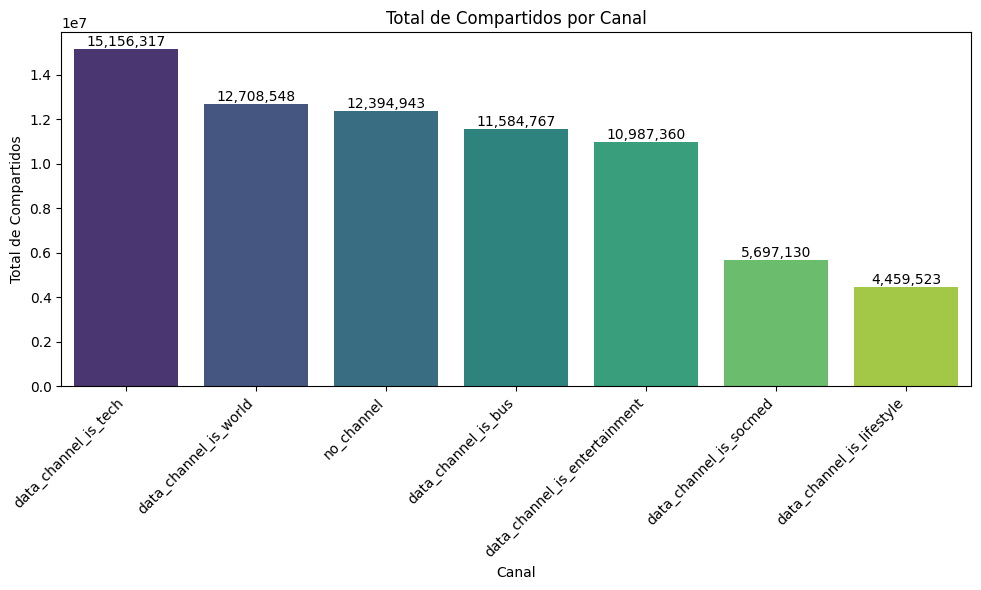

In [306]:
# Calcular cantidad de artículos por canal
channel_shares = df_clean[channel_cols].multiply(df_clean['shares'], axis=0).sum()

# Calcular cantidad de artículos sin canal
df_clean['no_channel_flag'] = (df_clean[channel_cols].sum(axis=1) == 0).astype(int)
no_channel_shares = df_clean[df_clean['no_channel_flag'] == 1]['shares'].sum()

# Agregar conteo de artículos sin canal
channel_shares['no_channel'] = no_channel_shares

# Conversión a dataframe
channel_shares_df = channel_shares.reset_index()
channel_shares_df.columns = ['Channel', 'Total Shares']
channel_shares_df = channel_shares_df.sort_values(by='Total Shares', ascending=False)

# Graficar el conteo de artículos por canal
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Channel', y='Total Shares', data=channel_shares_df, palette='viridis', hue='Channel', legend=False)
plt.title('Total de Compartidos por Canal')
plt.xlabel('Canal')
plt.ylabel('Total de Compartidos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Agrega etiquetas de datos
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

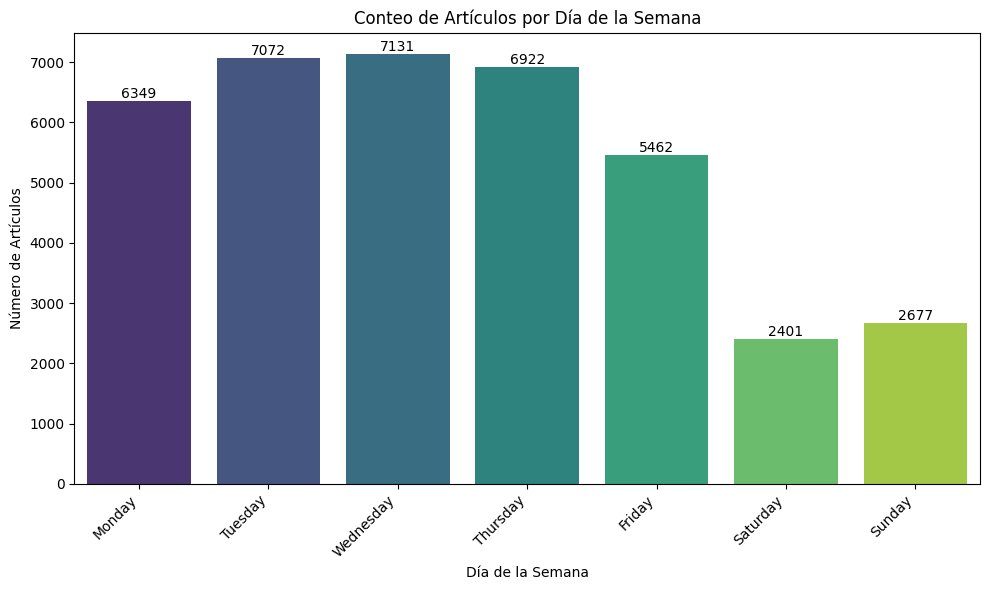

In [307]:
# Obten los días de la semana
weekday_cols = ['weekday_is_monday', 'weekday_is_tuesday', 'weekday_is_wednesday',
                'weekday_is_thursday', 'weekday_is_friday', 'weekday_is_saturday',
                'weekday_is_sunday']

# Cuenta los artículos pro día de la semana
weekday_counts = df_clean[weekday_cols].sum()

# Renombra columnas con los días de la semana
weekday_counts.index = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Grafica los artículos publicados por día de la semana
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=weekday_counts.index, y=weekday_counts.values, palette='viridis', hue=weekday_counts.index, legend=False) # Assign x to hue and set legend=False
plt.title('Conteo de Artículos por Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Número de Artículos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Añade etiqueta de datos
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

In [308]:
# Obten top 20 de artículos con más compartidos
top_20_articles = df_clean.sort_values(by='shares', ascending=False).head(20)

print("Top 20 articles with the most shares:")
display(top_20_articles[['url', 'shares']])

Top 20 articles with the most shares:

,url,shares
17770,http://mashable.com/2013/12/18/seventeen-joins...,8300.0
33356,http://mashable.com/2014/09/24/blackberry-pass...,8300.0
29849,http://mashable.com/2014/07/29/leonardo-dicapr...,8300.0
6333,http://mashable.com/2013/05/03/modern-disney-p...,8300.0
14072,http://mashable.com/2013/10/04/silk-road-by-th...,8300.0
6407,http://mashable.com/2013/05/06/best-movie-soun...,8300.0
1754,http://mashable.com/2013/02/06/6-year-old-film/,8300.0
31169,http://mashable.com/2014/08/20/onbeep/,8300.0
3237,http://mashable.com/2013/03/05/breakfast-food-...,8300.0
11179,http://mashable.com/2013/08/08/monuments-men-t...,8300.0


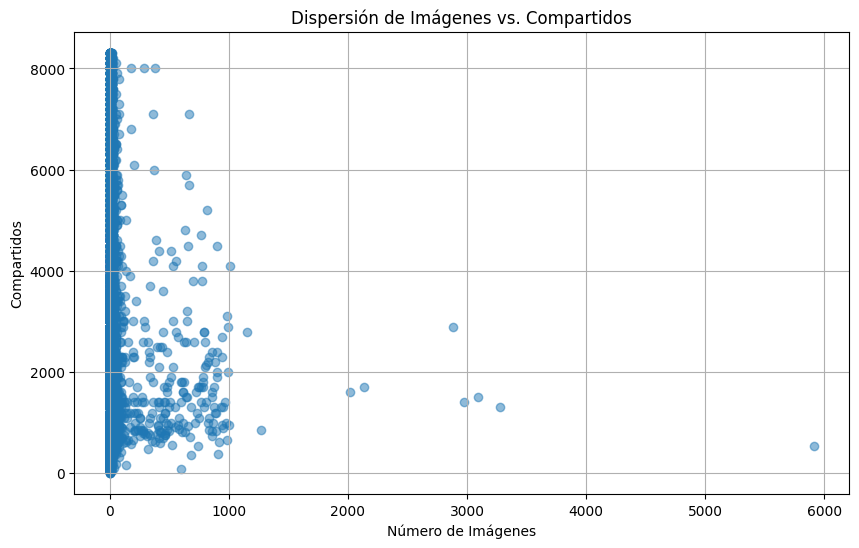

In [309]:
# Diagrama de dispersión de num_imgs vs shares
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['num_imgs'], df_clean['shares'], alpha=0.5)
plt.title('Dispersión de Imágenes vs. Compartidos')
plt.xlabel('Número de Imágenes')
plt.ylabel('Compartidos')
plt.grid(True)
plt.show()

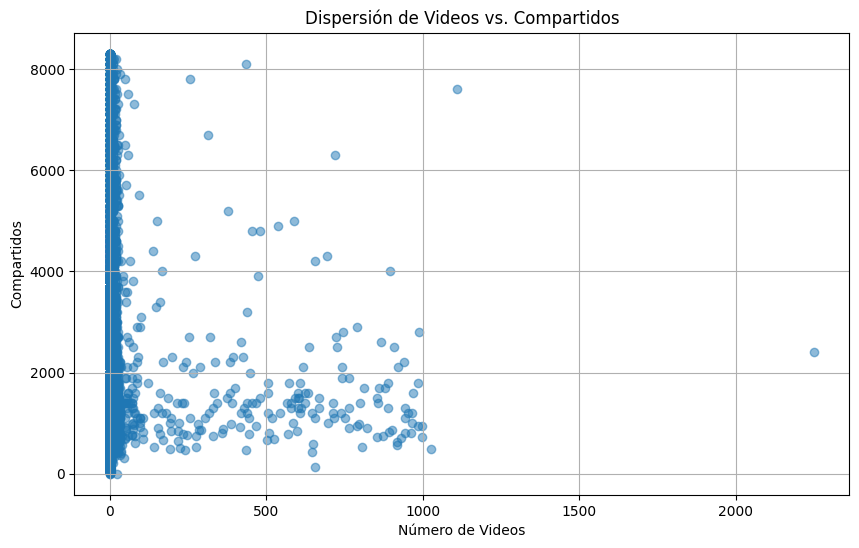

In [310]:
# Diagrama de dispersión de num_videos vs shares
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['num_videos'], df_clean['shares'], alpha=0.5)
plt.title('Dispersión de Videos vs. Compartidos')
plt.xlabel('Número de Videos')
plt.ylabel('Compartidos')
plt.grid(True)
plt.show()

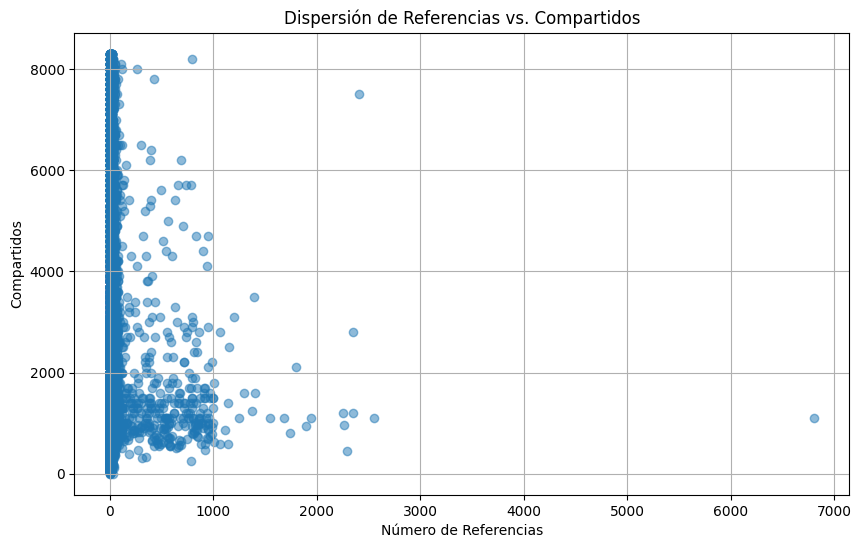

In [311]:
# Diagrama de dispersión de num_hrefs vs shares
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['num_hrefs'], df_clean['shares'], alpha=0.5)
plt.title('Dispersión de Referencias vs. Compartidos')
plt.xlabel('Número de Referencias')
plt.ylabel('Compartidos')
plt.grid(True)
plt.show()

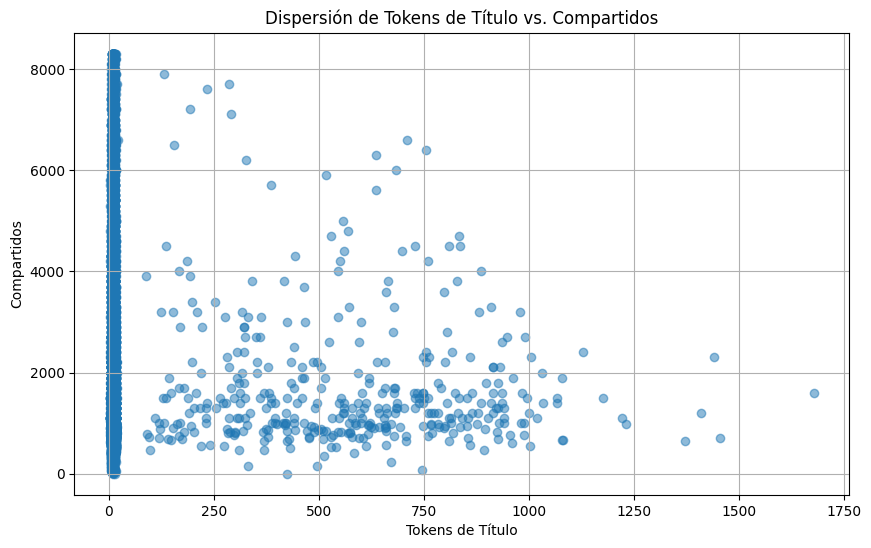

In [312]:
# Diagrama de dispersión de num_hrefs vs shares
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['n_tokens_title'], df_clean['shares'], alpha=0.5)
plt.title('Dispersión de Tokens de Título vs. Compartidos')
plt.xlabel('Tokens de Título')
plt.ylabel('Compartidos')
plt.grid(True)
plt.show()

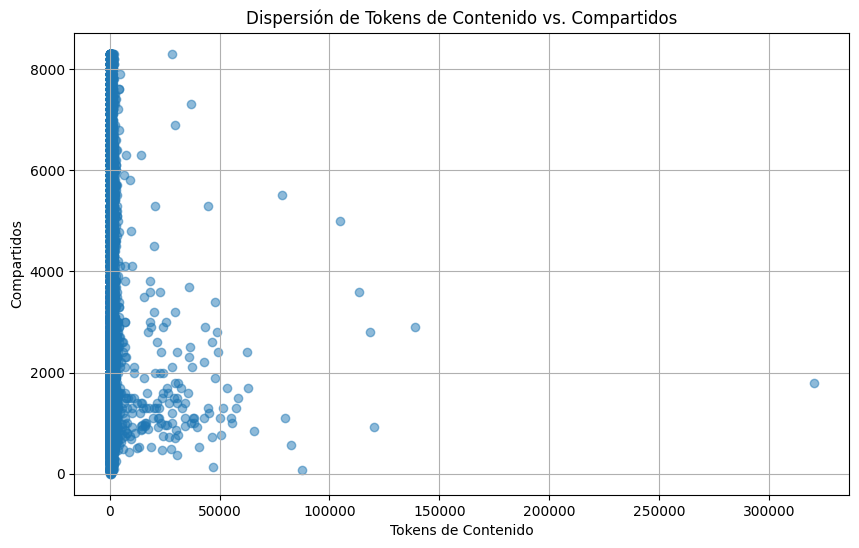

In [313]:
# Diagrama de dispersión de num_hrefs vs shares
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['n_tokens_content'], df_clean['shares'], alpha=0.5)
plt.title('Dispersión de Tokens de Contenido vs. Compartidos')
plt.xlabel('Tokens de Contenido')
plt.ylabel('Compartidos')
plt.grid(True)
plt.show()

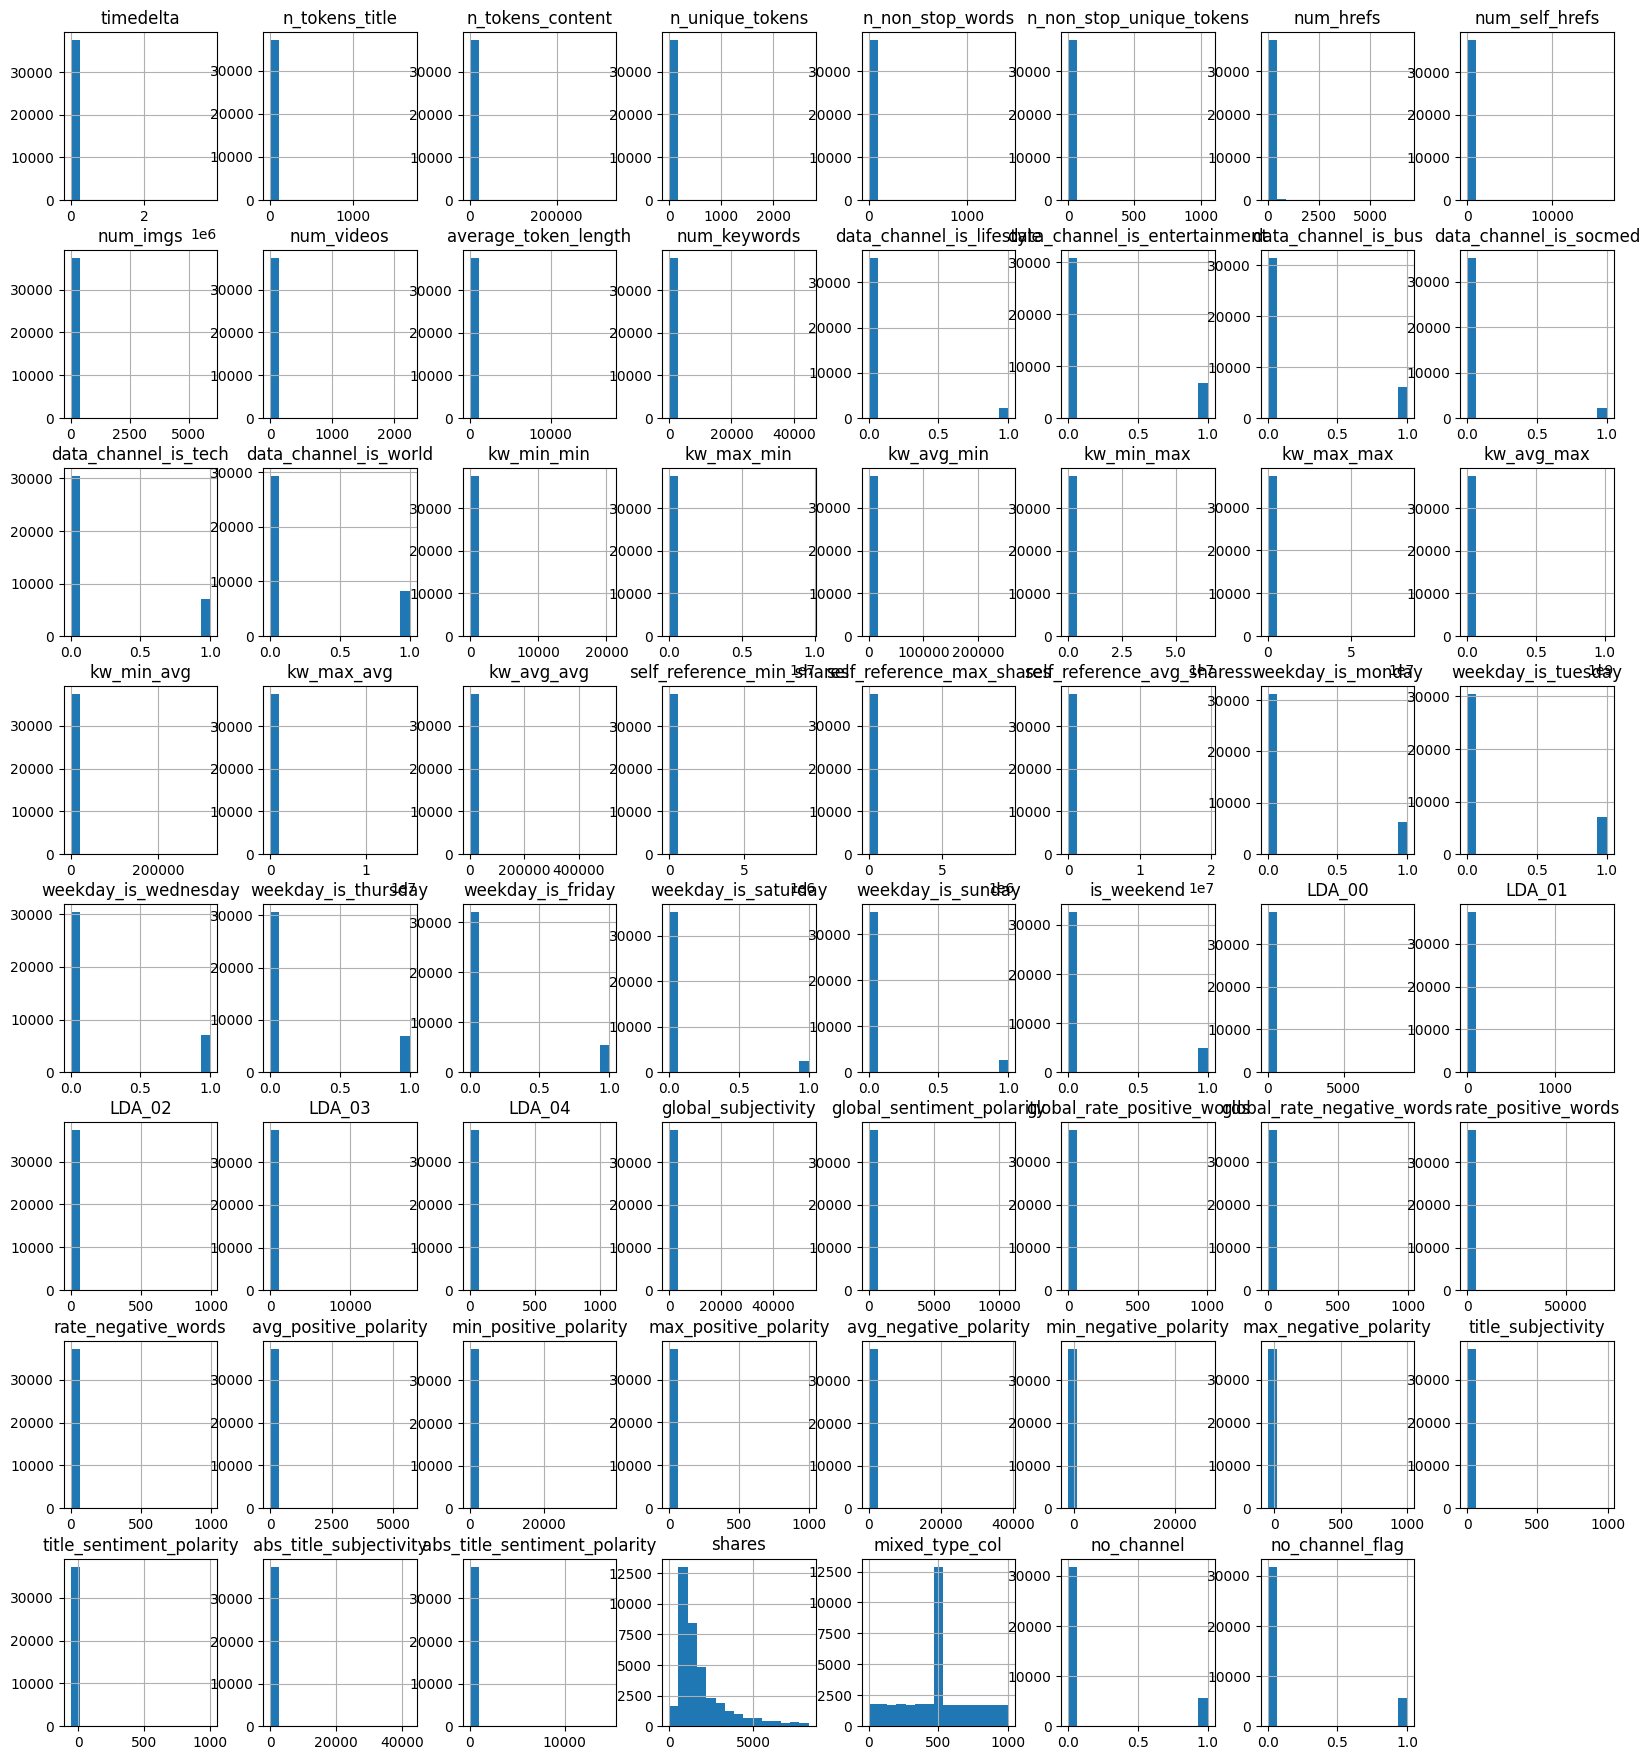

In [314]:
# Looking at the distributions
df_clean.hist(bins=15, figsize=(20, 22))
plt.show()

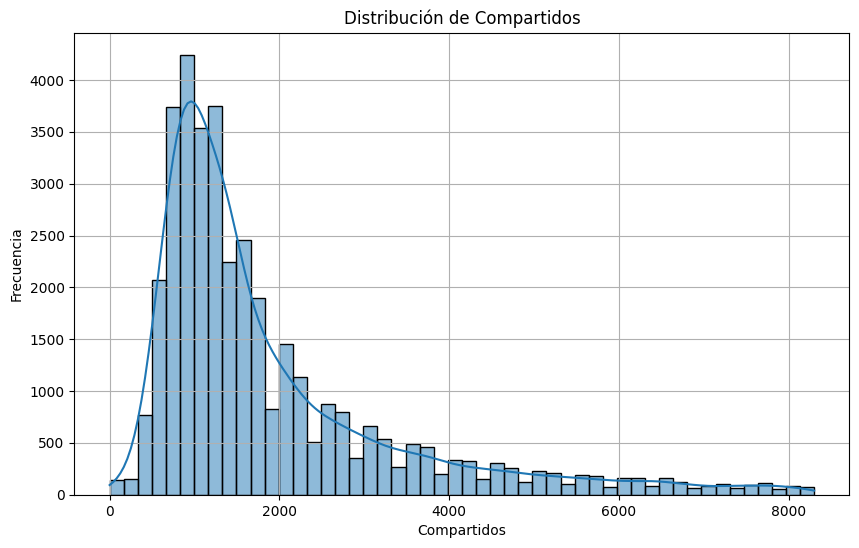

In [315]:
# Generar un histograma de la columna 'shares'
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['shares'], bins=50, kde=True)
plt.title('Distribución de Compartidos')
plt.xlabel('Compartidos')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

# **Parte 3**. Preprocesamiento y feature engineering

# *Preprocesamiento*

In [316]:
# Extraer fecha y título de la columna 'url'
# Manejar posibles valores NaN en la columna 'url'

# Convertir a cadena y eliminar espacios en blanco, creando la columna 'url_cleaned'
df_clean['url_cleaned'] = df_clean['url'].astype(str).str.strip()
commit_df_change(df_clean, "Create url_cleaned column")

# Usar regex para encontrar el patrón de fecha YYYY/MM/DD
date_pattern = r'/(\d{4})/(\d{2})/(\d{2})/'
date_match = df_clean['url_cleaned'].str.extract(date_pattern) # Extraer la fecha y guardarla en una variable temporal

df_clean['article_year'] = date_match[0]
df_clean['article_month'] = date_match[1]
df_clean['article_day'] = date_match[2]
commit_df_change(df_clean, "Create article year, month and day columns")

# Convertir columnas de fecha a numérico, forzando errores a NaN
df_clean['article_year'] = pd.to_numeric(df_clean['article_year'], errors='coerce')
df_clean['article_month'] = pd.to_numeric(df_clean['article_month'], errors='coerce')
df_clean['article_day'] = pd.to_numeric(df_clean['article_day'], errors='coerce')
commit_df_change(df_clean, "Force errors to NaN in date columns")

# Extraer título (última parte de la ruta URL antes de la barra final)
# Eliminar esquema, netloc y barra final, luego dividir por '/' y tomar la última parte
df_clean['article_title'] = df_clean['url_cleaned'].str.split('/').str[-2]
commit_df_change(df_clean, "Extract title from the last part of the URL")

# Modifica el nombre del artículo, inicia con mayúsculas y remueve guiones
df_clean['article_title'] = df_clean['article_title'].str.replace('-', ' ').str.title()
commit_df_change(df_clean, "Modified the article name")


print("Nuevas columnas 'article_year', 'article_month', 'article_day' y 'article_title' creadas y modificadas.")


display(df_clean[['url', 'article_year', 'article_month', 'article_day', 'article_title']].head())

Commit DVC creado: Create url_cleaned column
Commit DVC creado: Create article year, month and day columns
Commit DVC creado: Force errors to NaN in date columns
Commit DVC creado: Extract title from the last part of the URL
Commit DVC creado: Modified the article name
Nuevas columnas 'article_year', 'article_month', 'article_day' y 'article_title' creadas y modificadas.


,url,article_year,article_month,article_day,article_title
0,http://mashable.com/2013/01/07/amazon-instant-...,2013.0,1.0,7.0,Amazon Instant Video Browser
1,http://mashable.com/2013/01/07/ap-samsung-spon...,2013.0,1.0,7.0,Ap Samsung Sponsored Tweets
2,http://mashable.com/2013/01/07/apple-40-billio...,2013.0,1.0,7.0,Apple 40 Billion App Downloads
3,http://mashable.com/2013/01/07/astronaut-notre...,2013.0,1.0,7.0,Astronaut Notre Dame Bcs
4,http://mashable.com/2013/01/07/att-u-verse-apps/,2013.0,1.0,7.0,Att U Verse Apps


In [317]:
# Columnas booleanas para días de la semana
weekday_cols = ['weekday_is_monday', 'weekday_is_tuesday', 'weekday_is_wednesday',
                'weekday_is_thursday', 'weekday_is_friday', 'weekday_is_saturday',
                'weekday_is_sunday']
weekday_names = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']

# Crear la columna 'day_of_week'
def get_weekday_name(row):
    for i, col in enumerate(weekday_cols):
        if row[col] == 1:
            return weekday_names[i]
    return 'unknown' # Handle cases where no weekday is marked as 1

df_clean['day_of_week'] = df_clean[weekday_cols].apply(get_weekday_name, axis=1)
commit_df_change(df_clean, "Created Day of Week column")

print("Columna 'day_of_week' creada")


# Columnas booleanas para canales de datos
channel_cols = ['data_channel_is_lifestyle', 'data_channel_is_entertainment',
                'data_channel_is_bus', 'data_channel_is_socmed',
                'data_channel_is_tech', 'data_channel_is_world']
channel_names = ['lifestyle', 'entertainment', 'bus', 'socmed', 'tech', 'world']

# Crear la columna 'data_channel'
def get_channel_name(row):
    for i, col in enumerate(channel_cols):
        if row[col] == 1:
            return channel_names[i]
    return 'no_channel' # Handle cases where no channel is marked as 1

df_clean['data_channel'] = df_clean[channel_cols].apply(get_channel_name, axis=1)
commit_df_change(df_clean, "Created data channel column")

print("Columna 'data_channel' creada")


# Mostrar las primeras filas del dataframe con las nuevas columnas
print("\nPrimeras filas del dataframe con variables de día de semana y canal:")
display(df_clean[['day_of_week', 'data_channel']].head())

print("\nInformación del dataframe con las nuevas columnas:")
print(df_clean[['day_of_week', 'data_channel']].info())

print("\nFin del preprocesamiento")

Commit DVC creado: Created Day of Week column
Columna 'day_of_week' creada
Commit DVC creado: Created data channel column
Columna 'data_channel' creada

Primeras filas del dataframe con variables de día de semana y canal:


,day_of_week,data_channel
0,monday,entertainment
1,monday,bus
2,monday,bus
3,monday,entertainment
4,monday,tech



Información del dataframe con las nuevas columnas:
<class 'pandas.core.frame.DataFrame'>
Index: 37471 entries, 0 to 40434
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   day_of_week   37471 non-null  object
 1   data_channel  37471 non-null  object
dtypes: object(2)
memory usage: 878.2+ KB
None

Fin del preprocesamiento


# *Feature engeneering*

In [318]:
# Histograma y gráfico Q-Q para conocer comportamiento de las variables importantes

def diagnostic_plots(df_clean, variable):
    plt.figure(figsize=(10,4))
    plt.subplot(1, 2, 1)
    df_clean[variable].hist(bins=30, color='gray', edgecolor='black')
    plt.title(f"Histogram of {variable}")
    plt.subplot(1, 2, 2)
    stats.probplot(df_clean[variable], dist="norm", plot=plt)
    plt.gca().get_lines()[0].set_color('gray')
    plt.gca().get_lines()[1].set_color('red')
    plt.title(f"Q-Q plot of {variable}")
    plt.show()

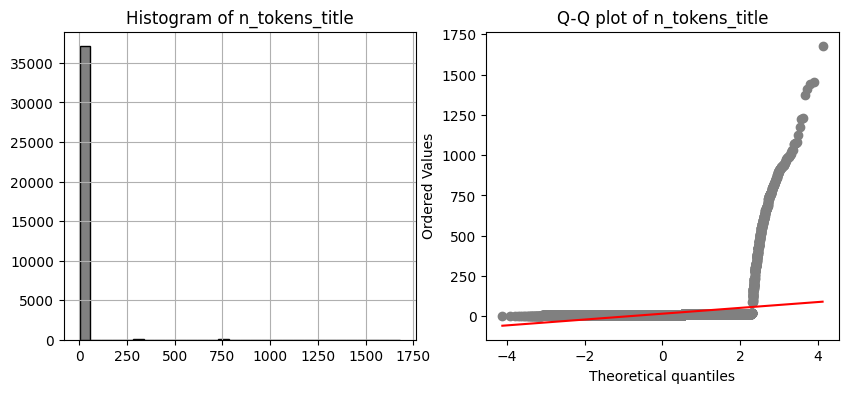

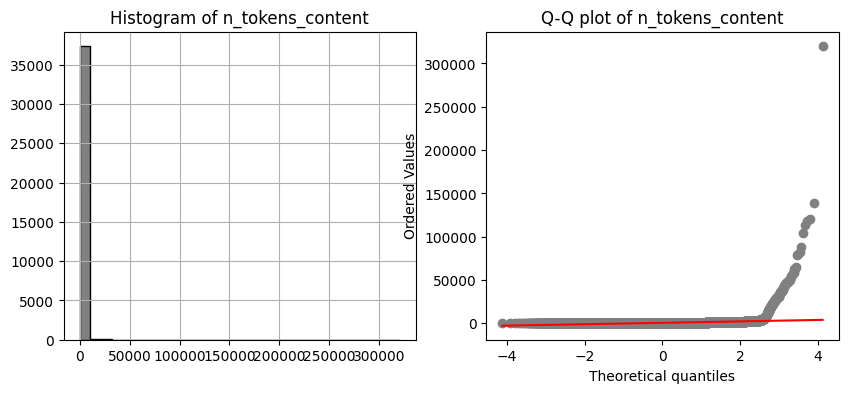

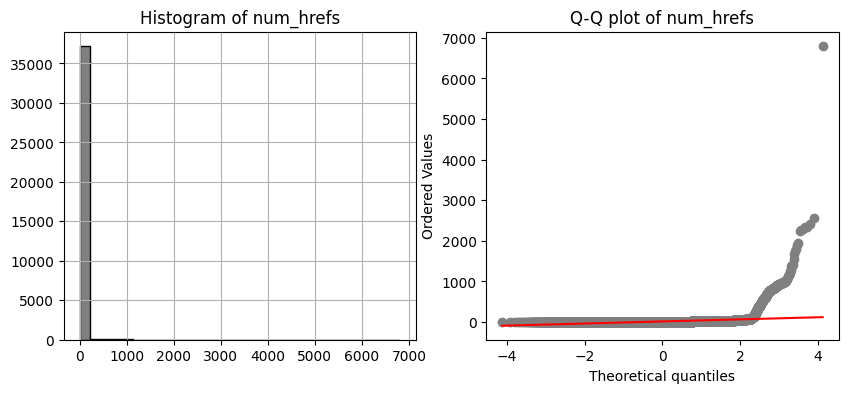

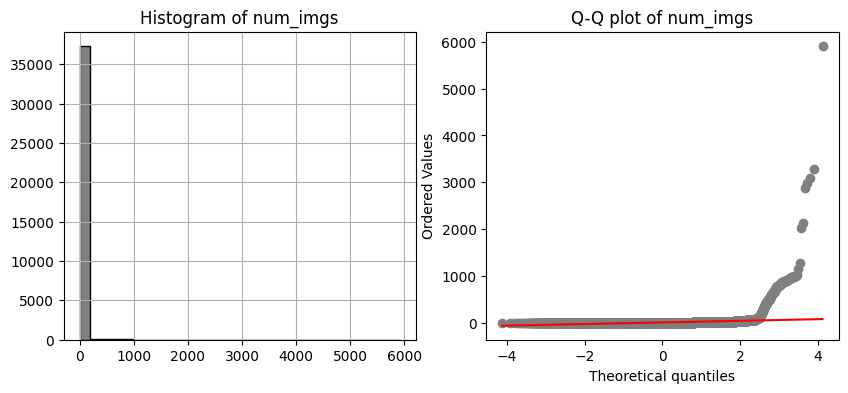

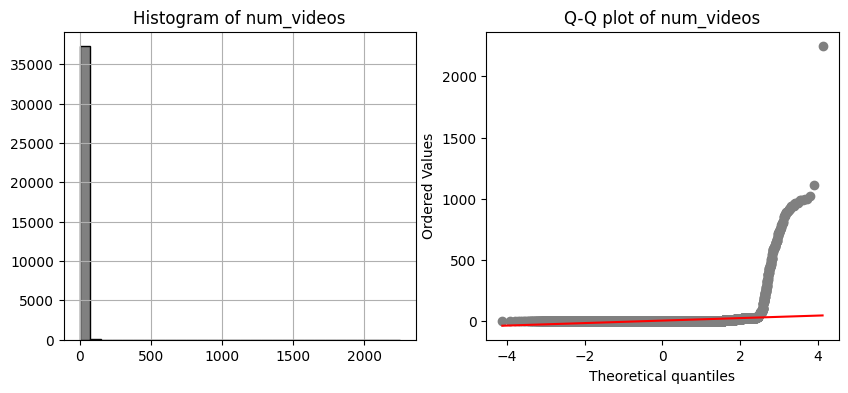

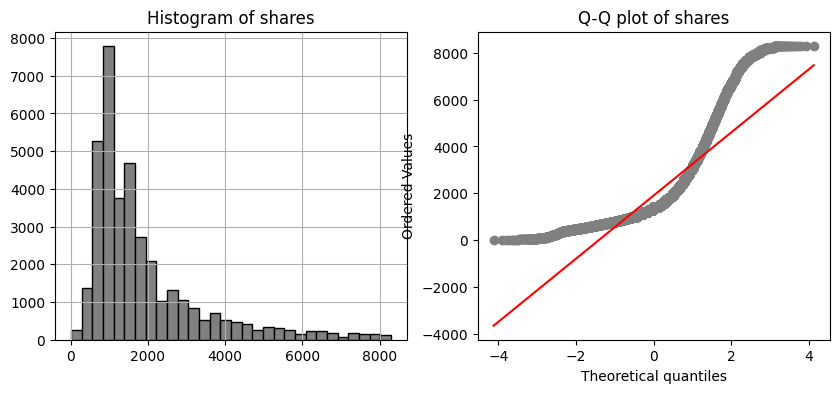

In [319]:
for col in df_clean[important_numeric_cols]:
    diagnostic_plots(df_clean, col)

In [320]:
#Transformación de las variables numéricas con método Yeo Jhonson

transformer = PowerTransformer(method="yeo-johnson", standardize=False)#Configuramos la transformación
transformer.fit(df_clean[important_numeric_cols])#Ajustamos el transformador
transf_df = pd.DataFrame(transformer.transform(df_clean[important_numeric_cols]), columns=important_numeric_cols, index=df_clean.index)#Transformamos cada variable del dataframe
print("Lambdas estimadas:", transformer.lambdas_)
print(transf_df.head())

Lambdas estimadas: [-1.09899599  0.21609636 -0.12660055 -0.5722886  -1.55574016 -0.03072561]
   n_tokens_title  n_tokens_content  num_hrefs  num_imgs  num_videos    shares
0        0.855623         10.216114   1.456063  0.572178        -0.0  5.799255
1        0.837477         10.710283   1.271458  0.572178        -0.0  5.947753
2        0.837477         10.097772   1.271458  0.572178        -0.0  6.550336
3        0.837477         13.336810   1.997340  0.572178        -0.0  6.371624
4        0.859870         16.277624   2.493143  1.441390        -0.0  5.667158


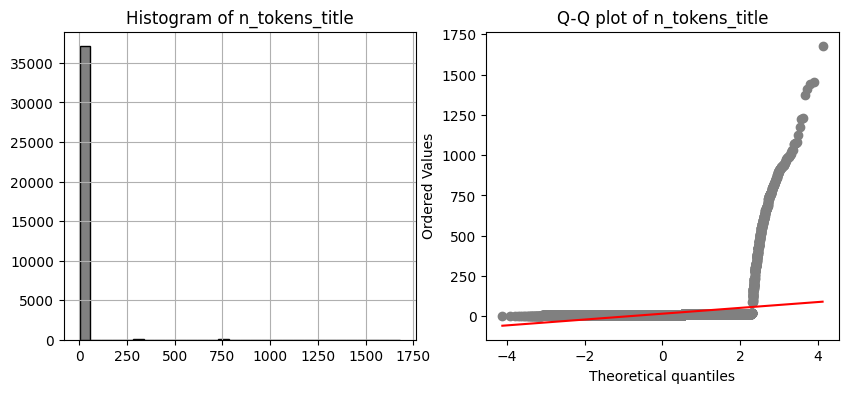

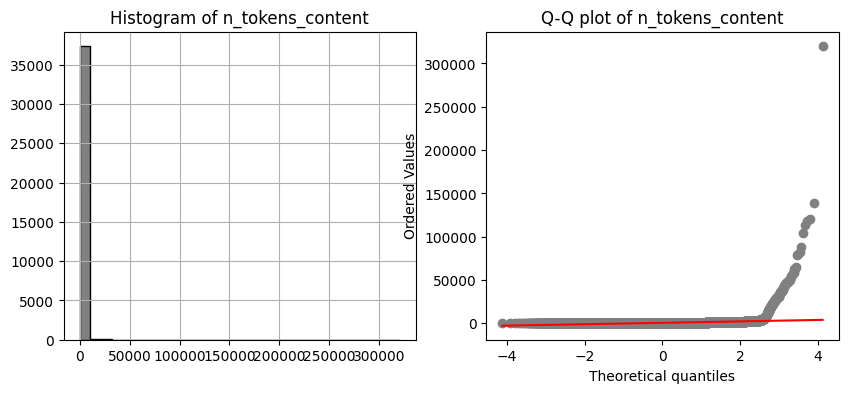

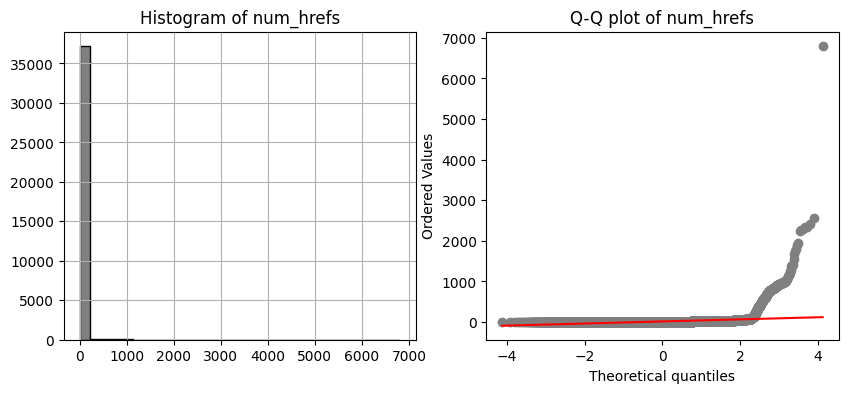

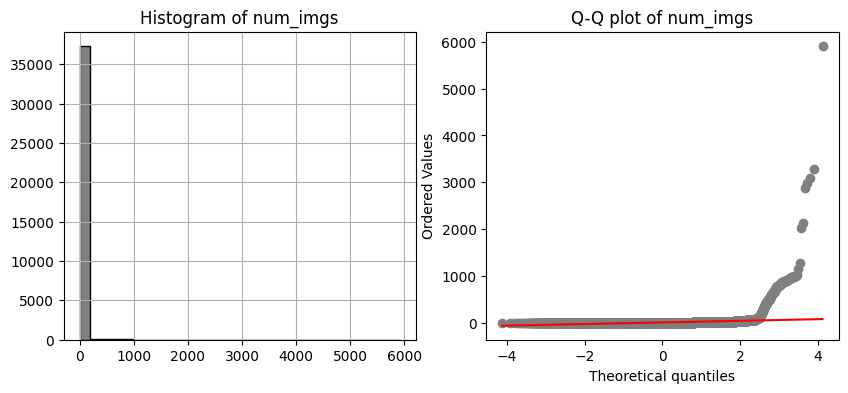

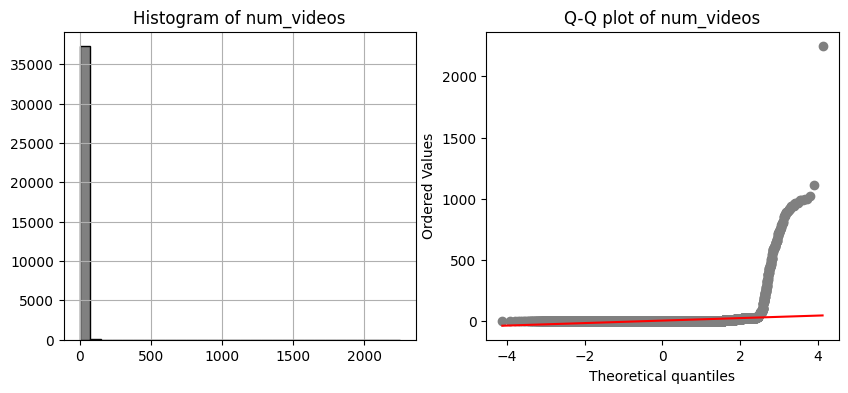

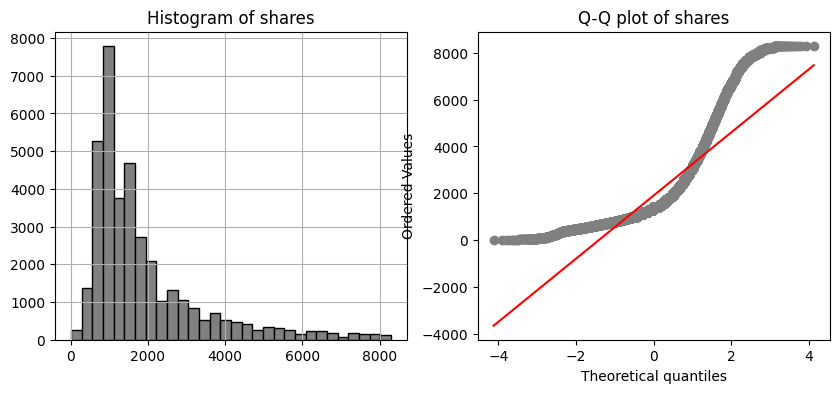

In [321]:
#Histograma y gráfico Q-Q para observar efecto de la transformación

for col in df_clean[important_numeric_cols]:
    diagnostic_plots(df_clean, col)

In [322]:
# Escalado de variables con min max
scaler=MinMaxScaler()
minmax_df = pd.DataFrame(scaler.fit_transform(transf_df), columns=transf_df.columns, index=transf_df.index)

print(minmax_df.head())

   n_tokens_title  n_tokens_content  num_hrefs  num_imgs  num_videos    shares
0        0.801176          0.152454   0.273966  0.329739         0.0  0.710665
1        0.734409          0.159828   0.239232  0.329739         0.0  0.731303
2        0.734409          0.150688   0.239232  0.329739         0.0  0.815050
3        0.734409          0.199023   0.375810  0.329739         0.0  0.790213
4        0.816802          0.242909   0.469098  0.830655         0.0  0.692306


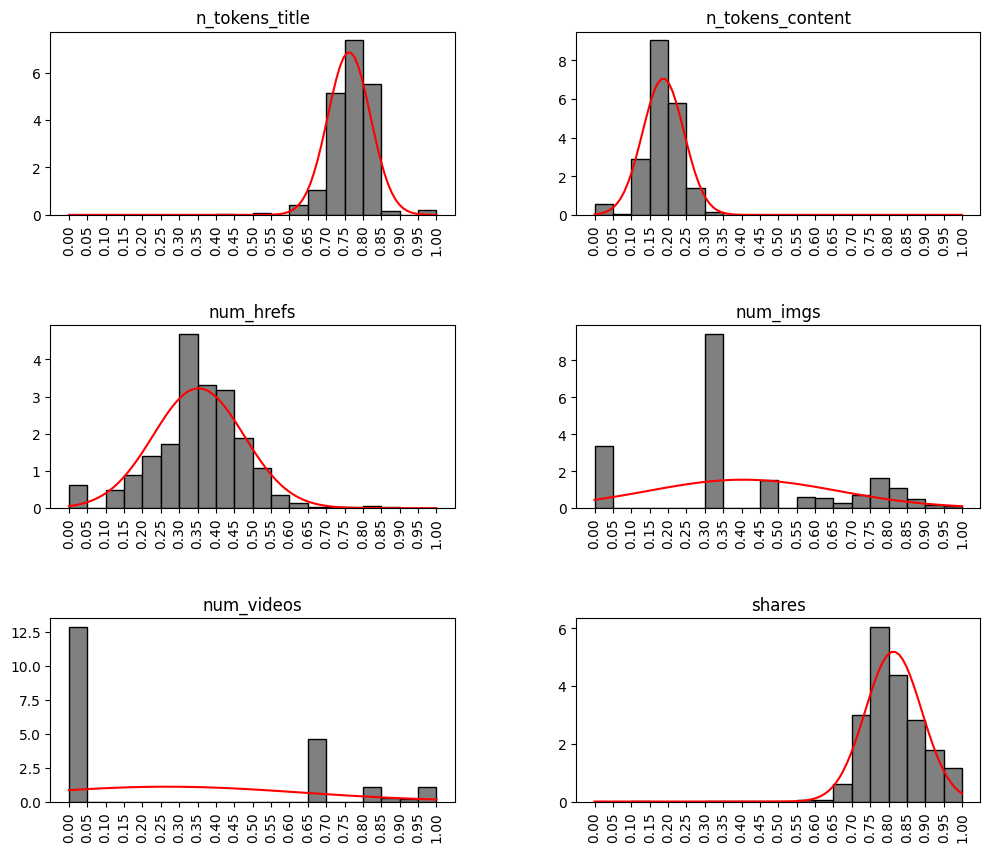

In [323]:
#Graficación de variables excaladas
fig, axes = plt.subplots(3,2, figsize=(12,10))
plt.subplots_adjust(wspace=.3, hspace=.6)

axes = axes.ravel()
for col, ax in zip(minmax_df.columns, axes):
  n, bins, edges = ax.hist(minmax_df[col], color='gray', bins=20, edgecolor='black', density=True)
  ax.set_xticks(bins)
  ax.tick_params(axis='x',rotation=90)
  ax.set(title=f'{col}', xlabel=None)

  x = np.linspace(np.min(minmax_df[col]), np.max(minmax_df[col]), 100)
  y = norm.pdf(x, np.mean(minmax_df[col]), np.std(minmax_df[col]))
  ax.plot(x, y, color='red')


In [324]:
# Renombra columnas de df min max agregando '_scaled' al final
minmax_df.columns = [col + '_scaled' for col in minmax_df.columns]
minmax_df.head()

,n_tokens_title_scaled,n_tokens_content_scaled,num_hrefs_scaled,num_imgs_scaled,num_videos_scaled,shares_scaled
0,0.801176,0.152454,0.273966,0.329739,0.0,0.710665
1,0.734409,0.159828,0.239232,0.329739,0.0,0.731303
2,0.734409,0.150688,0.239232,0.329739,0.0,0.815050
3,0.734409,0.199023,0.375810,0.329739,0.0,0.790213
4,0.816802,0.242909,0.469098,0.830655,0.0,0.692306


In [325]:
#Cardinalidad variables categoricas

var_categoricas = df_clean.describe(include='object').columns

highly_cardinal_variables = [];
few_cardinal_variables = [];

for col in var_categoricas:
  df_clean[col].nunique()
  if df_clean[col].nunique() >= 100:
    highly_cardinal_variables.append(col)
  else:
    few_cardinal_variables.append(col)
print(f'Variables con alta cardinalidad: {highly_cardinal_variables}')
print(f'Variables con baja cardinalidad: {few_cardinal_variables}')

Variables con alta cardinalidad: ['url', 'url_cleaned', 'article_title']
Variables con baja cardinalidad: ['day_of_week', 'data_channel']


In [326]:
# Codificar variables categóricas con baja cardinalidad

encoder = OneHotEncoder(drop='first')
encoded_data = encoder.fit_transform(df_clean[few_cardinal_variables])
onehot_df = pd.DataFrame(encoded_data.toarray(), columns=encoder.get_feature_names_out())
onehot_df

,day_of_week_monday,day_of_week_saturday,day_of_week_sunday,day_of_week_thursday,day_of_week_tuesday,day_of_week_unknown,day_of_week_wednesday,data_channel_entertainment,data_channel_lifestyle,data_channel_no_channel,data_channel_socmed,data_channel_tech,data_channel_world
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37466,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
37467,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
37468,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
37469,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [327]:
# Agrega variables escaladas al df
df_encoded = pd.concat([df_clean, minmax_df, onehot_df], axis=1)

print('Fin del feature engineering')

df_encoded.head()

Fin del feature engineering


,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,day_of_week_thursday,day_of_week_tuesday,day_of_week_unknown,day_of_week_wednesday,data_channel_entertainment,data_channel_lifestyle,data_channel_no_channel,data_channel_socmed,data_channel_tech,data_channel_world
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


# *FE VERSION 2*

In [339]:

# ========== 2) build_X_y (prepara X,y y fechas) ==========
def build_X_y(df_clean, keep_dates=False, random_state=42):
    base = df_clean.reset_index(drop=True).copy()   # índice limpio 0..N-1
    y = base['shares'].astype(float)                # variable objetivo

    # fechas base (Series alineable por posición) si existen year/month/day
    if {'article_year','article_month','article_day'}.issubset(df_clean.columns):
        dates0 = pd.to_datetime(
            df_clean[['article_year','article_month','article_day']].rename(
                columns={'article_year':'year','article_month':'month','article_day':'day'}
            ),
            errors='coerce'
        ).reset_index(drop=True)
    else:
        dates0 = pd.Series(np.arange(len(base)), index=range(len(base)))

    # elimina columnas de fecha del set de features si no se quieren usar
    date_cols = ['article_year','article_month','article_day','article_date']
    if not keep_dates:
        base = base.drop(columns=[c for c in date_cols if c in base.columns], errors='ignore')

    # numéricas a transformar (imputación simple con mediana)
    num_cols = ['n_tokens_title','n_tokens_content','num_hrefs','num_imgs','num_videos']
    for c in num_cols:
        if c in base.columns:
            base[c] = pd.to_numeric(base[c], errors='coerce').fillna(base[c].median())

    # one-hot para columnas categóricas (sin dejar las crudas)
    cat_cols = [c for c in ['day_of_week','data_channel'] if c in base.columns]
    try:
        ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
    except TypeError:  # compatibilidad con versiones viejas
        ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse=False)
    if cat_cols:
        ohe_mat = ohe.fit_transform(base[cat_cols])
        ohe_df = pd.DataFrame(ohe_mat, columns=ohe.get_feature_names_out(cat_cols), index=base.index)
    else:
        ohe_df = pd.DataFrame(index=base.index)

    # Yeo-Johnson (simetriza) + MinMax (0-1) a numéricas
    pt = PowerTransformer(method='yeo-johnson', standardize=False)
    transf_df = pd.DataFrame(pt.fit_transform(base[num_cols]), columns=num_cols, index=base.index)
    scaler = MinMaxScaler()
    minmax_df = pd.DataFrame(
        scaler.fit_transform(transf_df),
        columns=[f'{c}_scaled' for c in num_cols],
        index=base.index
    )

    # quita columnas que no entran como features (IDs, texto, target, crudas duplicadas)
    drop_cols = ['url','url_cleaned','article_title','shares'] + num_cols + cat_cols
    X_block = base.drop(columns=[c for c in drop_cols if c in base.columns], errors='ignore')

    # ensamble final de X y limpieza de infinitos
    X = pd.concat([X_block, minmax_df, ohe_df], axis=1).replace([np.inf, -np.inf], np.nan)

    # elimina filas con NaN en X o y; alinea fechas por posición
    bad = X.isna().any(axis=1) | y.isna()
    if bad.sum():
        X = X.loc[~bad].copy()
        y = y.loc[~bad].copy()
    dates = dates0.iloc[X.index]

    return X, y, dates, pt, scaler, ohe


# *ML MODELS IMPLEMENTATION*

# Funciones Auxliares

In [330]:
# ========== 1) Funciones auxiliares ==========
def _safe_mape(y_true, y_pred):
    # MAPE (%) ignorando casos con y_true=0 para evitar división por cero
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)

def evaluate_regression(y_true, y_pred, label=""):
    # Métricas principales de regresión (valores bajos mejores salvo R2)
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    abs_err = np.abs(y_true - y_pred)
    return {
        "label": label,
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(mean_squared_error(y_true, y_pred, squared=False)),
        "R2": float(r2_score(y_true, y_pred)),
        "MedAE": float(np.median(abs_err)),
        "MAPE%": _safe_mape(y_true, y_pred),
        "P90_AE": float(np.percentile(abs_err, 90)),
        "n": int(len(y_true)),
    }

def save_artifacts(name, estimator, y_test, y_pred, metrics):
    # guarda el modelo y un CSV con y_true/y_pred del test
    joblib.dump(estimator, f"models/{name}.joblib")
    pd.DataFrame({"y_true": y_test, "y_pred": y_pred}).to_csv(
        f"predictions/{name}_test.csv", index=False
    )
    print(f"[guardado] models/{name}.joblib  |  predictions/{name}_test.csv")
    print(metrics)

def temporal_split(X, y, dates, test_size=0.2, n_splits=5):
    # split temporal 80/20 según 'dates' y generador de CV temporal
    order = dates.sort_values().index if isinstance(dates, pd.Series) else X.index
    cut = int((1 - test_size) * len(order))
    train_idx, test_idx = order[:cut], order[cut:]
    X_train, X_test = X.loc[train_idx].copy(), X.loc[test_idx].copy()
    y_train, y_test = y.loc[train_idx].copy(), y.loc[test_idx].copy()
    cv = TimeSeriesSplit(n_splits=n_splits)
    return X_train, X_test, y_train, y_test, cv



# Split de Datos de entrenamiento y prueba

In [ ]:
# ========== 3) Construcción de X,y y split temporal ==========
X, y, dates, pt, scaler, ohe = build_X_y(df_clean, keep_dates=False)
print("Shapes:", X.shape, y.shape)
print("Nulos totales en X:", int(X.isna().sum().sum()))

X_train, X_test, y_train, y_test, cv = temporal_split(X, y, dates, test_size=0.2, n_splits=5)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

feature_cols = X_train.columns.tist()  # todas las columnas de X para los modelos
print(f"Features usadas: {len(feature_cols)}")

results = []  # aquí guardamos diccionarios de métricas de cada modelo

Shapes: (37471, 75) (37471,)
Nulos totales en X: 0
Train: (29976, 75), Test: (7495, 75)
Features usadas: 75


# MODELO 1 - REGRESION RIDGE Y LASSO (ELASTICNET)

In [341]:
# ========== 4) MODELO 1 — ElasticNet (y en log1p) ==========
# escalado -> ElasticNet, y envuelto en TTR para aplicar log1p/expm1 al target
enet_pipe = Pipeline(steps=[
    ("scaler", StandardScaler(with_mean=False)),
    ("enet", ElasticNet(max_iter=20000, random_state=42))
])
enet_ttr = TransformedTargetRegressor(
    regressor=enet_pipe, func=np.log1p, inverse_func=np.expm1, check_inverse=False
)

# búsqueda aleatoria de hiperparámetros (optimiza MAE con CV temporal)
param_enet = {
    "regressor__enet__alpha": loguniform(1e-4, 10.0),
    "regressor__enet__l1_ratio": uniform(0.0, 1.0),
}
search_enet = RandomizedSearchCV(
    estimator=enet_ttr,
    param_distributions=param_enet,
    n_iter=50,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search_enet.fit(X_train[feature_cols], y_train)            # entrena con CV temporal
y_pred_enet = search_enet.predict(X_test[feature_cols])    # predice en test

m_enet = evaluate_regression(y_test, y_pred_enet, "ElasticNet_log1p")
save_artifacts("elasticnet_log1p", search_enet.best_estimator_, y_test, y_pred_enet, m_enet)
results.append(m_enet)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[guardado] models/elasticnet_log1p.joblib  |  predictions/elasticnet_log1p_test.csv
{'label': 'ElasticNet_log1p', 'MAE': 890.344538381049, 'RMSE': 1450.6910949027588, 'R2': 0.003310756337110865, 'MedAE': 531.3196199981157, 'MAPE%': 68.27456827805229, 'P90_AE': 2173.821104852749, 'n': 7495}


# MODELO 2 - HISTGRADIENTBOOSTING

In [342]:
# ========== 5) MODELO 2 — HistGradientBoosting (Poisson) ==========
# boosting por histogramas, adecuado para conteos no negativos
hgb = HistGradientBoostingRegressor(
    loss="poisson",
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15,   # porción del train para parar temprano
    n_iter_no_change=20,        # paciencia antes de cortar
    tol=1e-4,                   # umbral de mejora mínima
    max_bins=255
)

# espacio de hiperparámetros afinado; 
param_hgb = {
    "learning_rate": loguniform(0.01, 0.12),
    "max_iter": randint(200, 600),
    "max_depth": randint(3, 10),
    "max_leaf_nodes": randint(24, 140),
    "min_samples_leaf": randint(15, 120),
    "l2_regularization": loguniform(1e-9, 1e-2),
}

search_hgb = RandomizedSearchCV(
    estimator=hgb,
    param_distributions=param_hgb,
    n_iter=40,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search_hgb.fit(X_train[feature_cols], y_train)
print("Mejor HGB (Poisson):", search_hgb.best_params_, "| MAE CV:", -search_hgb.best_score_)
y_pred_hgb = search_hgb.predict(X_test[feature_cols])

m_hgb = evaluate_regression(y_test, y_pred_hgb, "HistGB_Poisson")
save_artifacts("histgb_poisson", search_hgb.best_estimator_, y_test, y_pred_hgb, m_hgb)
results.append(m_hgb)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Mejor HGB (Poisson): {'l2_regularization': 0.0023186906702901996, 'learning_rate': 0.019022627470873063, 'max_depth': 6, 'max_iter': 201, 'max_leaf_nodes': 29, 'min_samples_leaf': 68} | MAE CV: 1071.2805387265591
[guardado] models/histgb_poisson.joblib  |  predictions/histgb_poisson_test.csv
{'label': 'HistGB_Poisson', 'MAE': 944.8131731473752, 'RMSE': 1359.3013787954314, 'R2': 0.12493281939518253, 'MedAE': 692.5730804456166, 'MAPE%': 82.63109959028775, 'P90_AE': 1790.335438243864, 'n': 7495}


# MODELO 3 -RANDOM FOREST

In [343]:
# ========== 6) MODELO 3 — RandomForest ==========
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1,
    bootstrap=True,
)

# rango de búsqueda práctico para sesgo/varianza y tiempo de entrenamiento
rf_param = {
    "n_estimators": randint(300, 700),
    "max_depth": randint(8, 24),
    "max_features": ["sqrt", 0.4, 0.6],
    "min_samples_split": randint(2, 12),
    "min_samples_leaf": randint(1, 6),
    "max_samples": [None, 0.70, 0.85, 0.95],
    "ccp_alpha": loguniform(1e-6, 1e-3),
}

cv_fast = TimeSeriesSplit(n_splits=3)  # CV más corto para acelerar

search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param,
    n_iter=25,
    scoring="neg_mean_absolute_error",
    cv=cv_fast,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search_rf.fit(X_train[feature_cols], y_train)
y_pred_rf = search_rf.predict(X_test[feature_cols])

m_rf = evaluate_regression(y_test, y_pred_rf, "RandomForest")
save_artifacts("randomforest", search_rf.best_estimator_, y_test, y_pred_rf, m_rf)
results.append(m_rf)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
[guardado] models/randomforest.joblib  |  predictions/randomforest_test.csv
{'label': 'RandomForest', 'MAE': 970.2309201424431, 'RMSE': 1364.3979417363064, 'R2': 0.11835856605732886, 'MedAE': 741.3381394230291, 'MAPE%': 87.57646607777745, 'P90_AE': 1779.7892506956034, 'n': 7495}


# MODELO 4 - RED NEURONAL (MLP)

In [344]:
# ========== 7) MODELO 4 — MLP (pequeño, early_stopping) + TTR ==========
# escalado -> MLP; objetivo transformado en log1p para estabilizar
mlp_pipe = Pipeline(steps=[
    ("scaler", StandardScaler(with_mean=False)),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        learning_rate_init=1e-3,
        alpha=1e-4,
        batch_size=512,
        max_iter=400,
        early_stopping=True,
        n_iter_no_change=15,
        random_state=42
    ))
])

mlp_ttr = TransformedTargetRegressor(
    regressor=mlp_pipe,
    func=np.log1p, inverse_func=np.expm1,
    check_inverse=False
)

# búsqueda compacta para no alargar tiempos
param_mlp = {
    "regressor__mlp__hidden_layer_sizes": [(64,), (128,), (64,32), (128,64)],
    "regressor__mlp__alpha": loguniform(1e-6, 1e-2),
    "regressor__mlp__learning_rate_init": loguniform(1e-4, 5e-3),
    "regressor__mlp__activation": ["relu", "tanh"],
    "regressor__mlp__batch_size": [256, 512, 1024],
}

search_mlp = RandomizedSearchCV(
    estimator=mlp_ttr,
    param_distributions=param_mlp,
    n_iter=25,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search_mlp.fit(X_train[feature_cols], y_train)
y_pred_mlp = search_mlp.predict(X_test[feature_cols])

m_mlp = evaluate_regression(y_test, y_pred_mlp, "MLP_log1p")
save_artifacts("mlp_log1p", search_mlp.best_estimator_, y_test, y_pred_mlp, m_mlp)
results.append(m_mlp)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[guardado] models/mlp_log1p.joblib  |  predictions/mlp_log1p_test.csv
{'label': 'MLP_log1p', 'MAE': 889.1368721337315, 'RMSE': 1451.5769995571536, 'R2': 0.002093072919076011, 'MedAE': 518.2813434592354, 'MAPE%': 67.51333199563275, 'P90_AE': 2164.8660732580643, 'n': 7495}


# TABLA COMPARATIVA DE METRICAS DE DESEMPEÑO

In [345]:
# ========== 7) Resumen comparativo (numérico) ==========
leaderboard = pd.DataFrame(results).sort_values(["RMSE", "MAE"])  # convierte la lista de métricas en DataFrame y ordena (menor RMSE y luego MAE)
print("\nResumen de modelos (mejor = menor RMSE/MAE):")             # encabezado legible en la salida
print(leaderboard.to_string(index=False))                           # muestra la tabla completa sin índice


Resumen de modelos (mejor = menor RMSE/MAE):
           label        MAE        RMSE       R2      MedAE     MAPE%      P90_AE    n
  HistGB_Poisson 944.813173 1359.301379 0.124933 692.573080 82.631100 1790.335438 7495
    RandomForest 970.230920 1364.397942 0.118359 741.338139 87.576466 1779.789251 7495
ElasticNet_log1p 890.344538 1450.691095 0.003311 531.319620 68.274568 2173.821105 7495
       MLP_log1p 889.136872 1451.577000 0.002093 518.281343 67.513332 2164.866073 7495
